<a href="https://colab.research.google.com/github/binhminh276/hcmc-house-price_prediction/blob/main/notebooks/08_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
file_path = 'processed_dataset_cleaned_new.csv'
df = pd.read_csv(file_path, sep=';',decimal = ',')

In [ ]:
df

,ID,Diện tích,Khoảng giá,Số phòng ngủ,"Số phòng tắm, vệ sinh",Pháp lý,Nội thất,Ngày hết hạn,Mặt tiền,Gần bệnh viện,Gần chợ,Gần trường học,Cao tầng,Quy hoạch,Phường,Quận,Giá m2
0,1,54.0,8.50,3,4,Không rõ,Không rõ,18/03/2026,0,0,0,0,1,0,Phường 5,Gò Vấp,0.157407
1,2,28.4,7.00,3,3,Sổ riêng,Nội thất cơ bản,18/03/2026,1,1,1,0,1,0,Phường 4,Quận 1,0.246479
2,3,69.0,3.30,3,3,Sổ riêng,Không rõ,16/03/2026,1,0,1,1,1,0,Phường Long Phước,Thủ Đức,0.047826
3,4,78.2,6.95,3,3,Sổ riêng,Không rõ,18/03/2026,1,0,0,0,1,0,Phường Trường Thọ,Thủ Đức,0.088875
4,5,75.9,6.70,2,2,Sổ riêng,Không rõ,18/03/2026,1,0,0,0,0,1,Phường Linh Tây,Thủ Đức,0.088274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11244,11324,71.0,6.90,3,3,Không rõ,Không rõ,13/03/2026,0,0,0,0,1,0,Phường 16,Gò Vấp,0.097183
11245,11325,81.1,7.15,4,6,Sổ riêng,Full nội thất,11/03/2026,0,0,1,1,0,0,Phường Thới An,Quận 1,0.088163
11246,11326,23.0,2.50,2,3,Sổ riêng,Không rõ,13/03/2026,0,1,1,0,1,1,Phường Linh Xuân,Thủ Đức,0.108696
11247,11327,100.0,18.50,4,3,Sổ riêng,Không rõ,16/03/2026,1,0,0,0,1,0,Phường 14,Phú Nhuận,0.185000


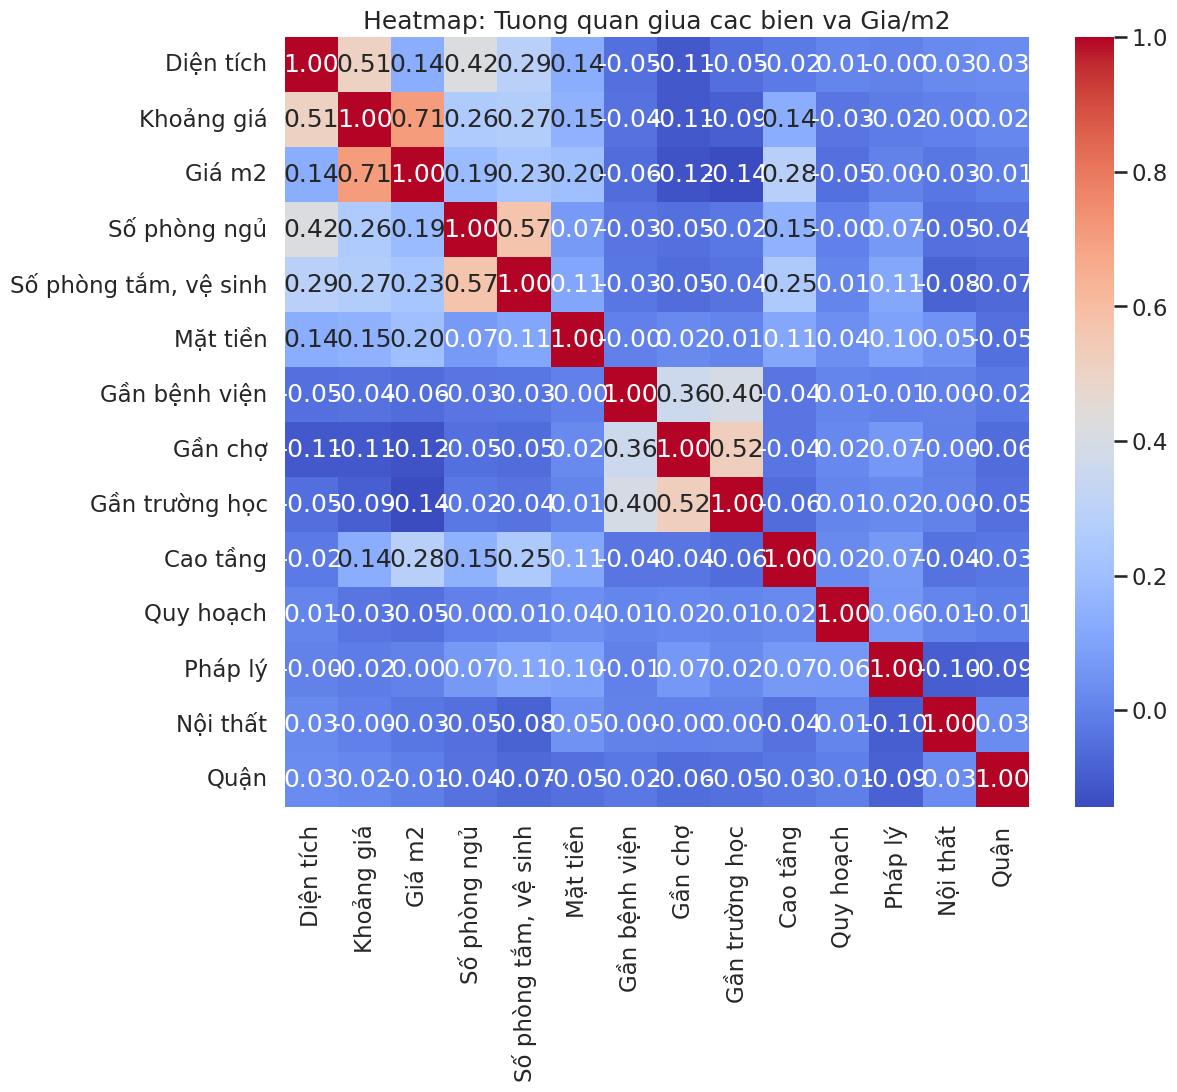

In [ ]:
df_corr = df.copy()
le = LabelEncoder()

for col in ['Pháp lý', 'Nội thất', 'Quận']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

features = [
    'Diện tích', 'Khoảng giá', 'Giá m2', 'Số phòng ngủ',
    'Số phòng tắm, vệ sinh', 'Mặt tiền', 'Gần bệnh viện',
    'Gần chợ', 'Gần trường học', 'Cao tầng', 'Quy hoạch',
    'Pháp lý', 'Nội thất', 'Quận'
]

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap: Tuong quan giua cac bien va Gia/m2')
plt.show()

# Diện tích và các yếu tố liên quan

/tmp/ipykernel_7268/114795150.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


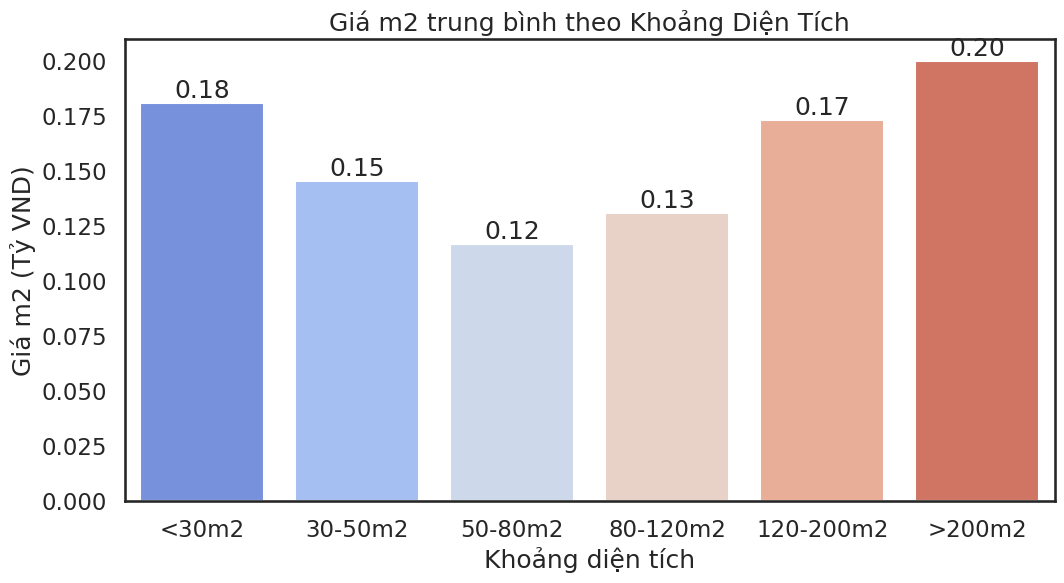

In [ ]:
bins = [0, 30, 50, 80, 120, 200, df['Diện tích'].max()]
labels = ['<30m2', '30-50m2', '50-80m2', '80-120m2', '120-200m2', '>200m2']
df['Khoang_Dien_Tich'] = pd.cut(df['Diện tích'], bins=bins, labels=labels)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Khoang_Dien_Tich',
    y='Giá m2',
    data=df,
    palette='coolwarm',
    errorbar=None
)

plt.title('Giá m2 trung bình theo Khoảng Diện Tích')
plt.xlabel('Khoảng diện tích')
plt.ylabel('Giá m2 (Tỷ VND)')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.show()

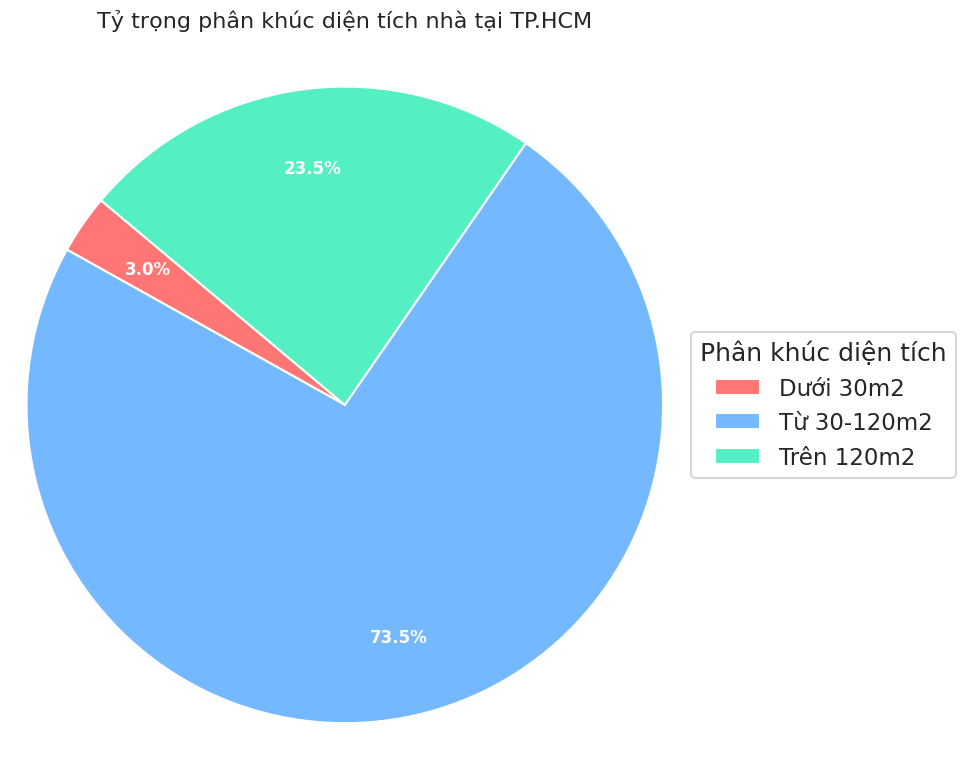

In [ ]:
bins = [0, 30, 120, float('inf')]
labels = ['Dưới 30m2', 'Từ 30-120m2', 'Trên 120m2']
df['Phân khúc DT'] = pd.cut(df['Diện tích'], bins=bins, labels=labels)
data = df['Phân khúc DT'].value_counts().reindex(labels)

colors = ['#ff7675', '#74b9ff', '#55efc4']

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    data,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75
)

plt.legend(
    wedges,
    data.index,
    title="Phân khúc diện tích",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.setp(autotexts, size=12, weight="bold", color="white")

plt.title('Tỷ trọng phân khúc diện tích nhà tại TP.HCM', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

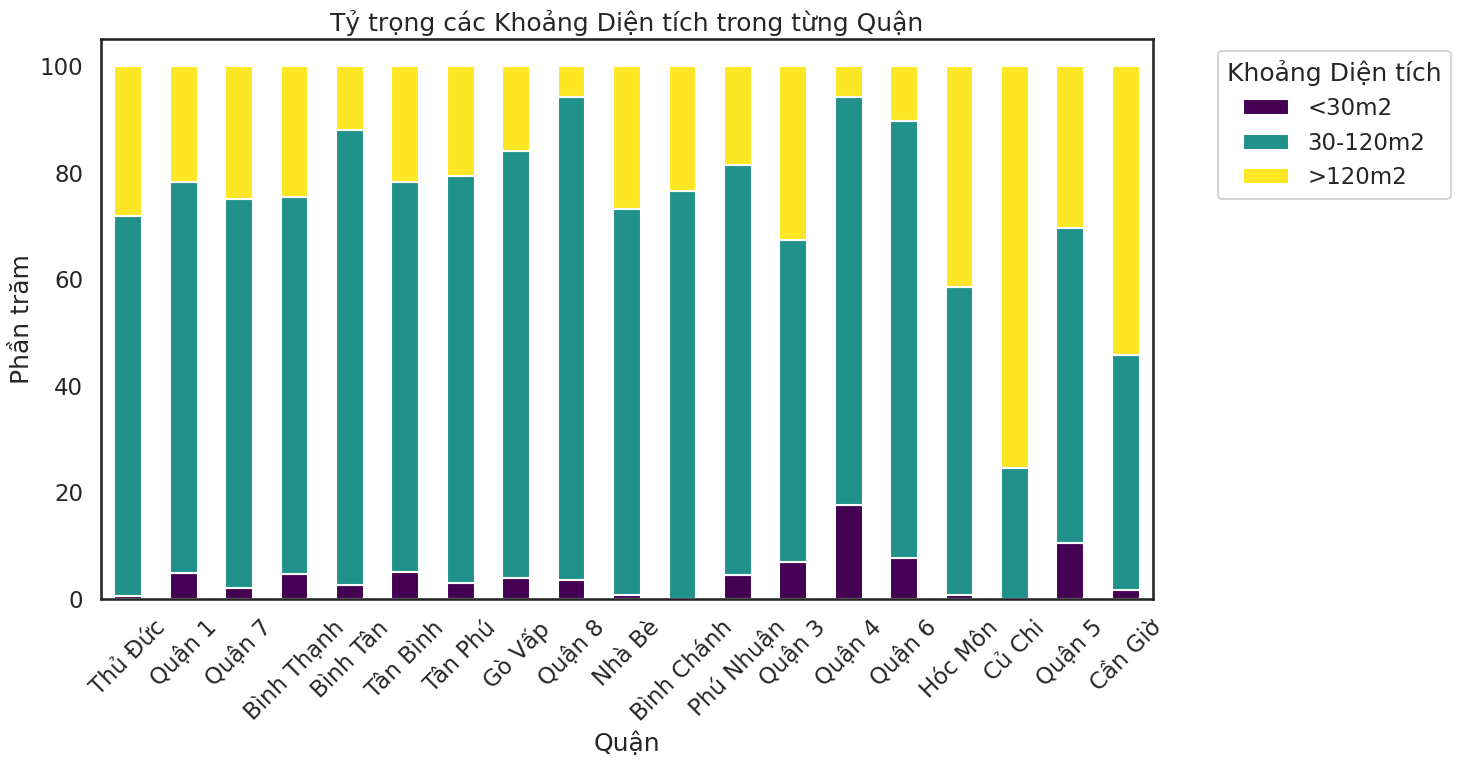

In [ ]:
bins = [0, 30, 120, float('inf')]
labels = ['<30m2', '30-120m2', '>120m2']
df['Khoang_Dien_Tich'] = pd.cut(df['Diện tích'], bins=bins, labels=labels)

dist_area_dist = pd.crosstab(df['Quận'], df['Khoang_Dien_Tich'])

dist_area_dist['Total'] = dist_area_dist.sum(axis=1)
dist_area_dist = dist_area_dist.sort_values(by='Total', ascending=False).drop(columns='Total')

dist_area_pct = dist_area_dist.div(dist_area_dist.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 8))
dist_area_pct.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')

plt.title('Tỷ trọng các Khoảng Diện tích trong từng Quận')
plt.xlabel('Quận')
plt.ylabel('Phần trăm')
plt.legend(title='Khoảng Diện tích', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

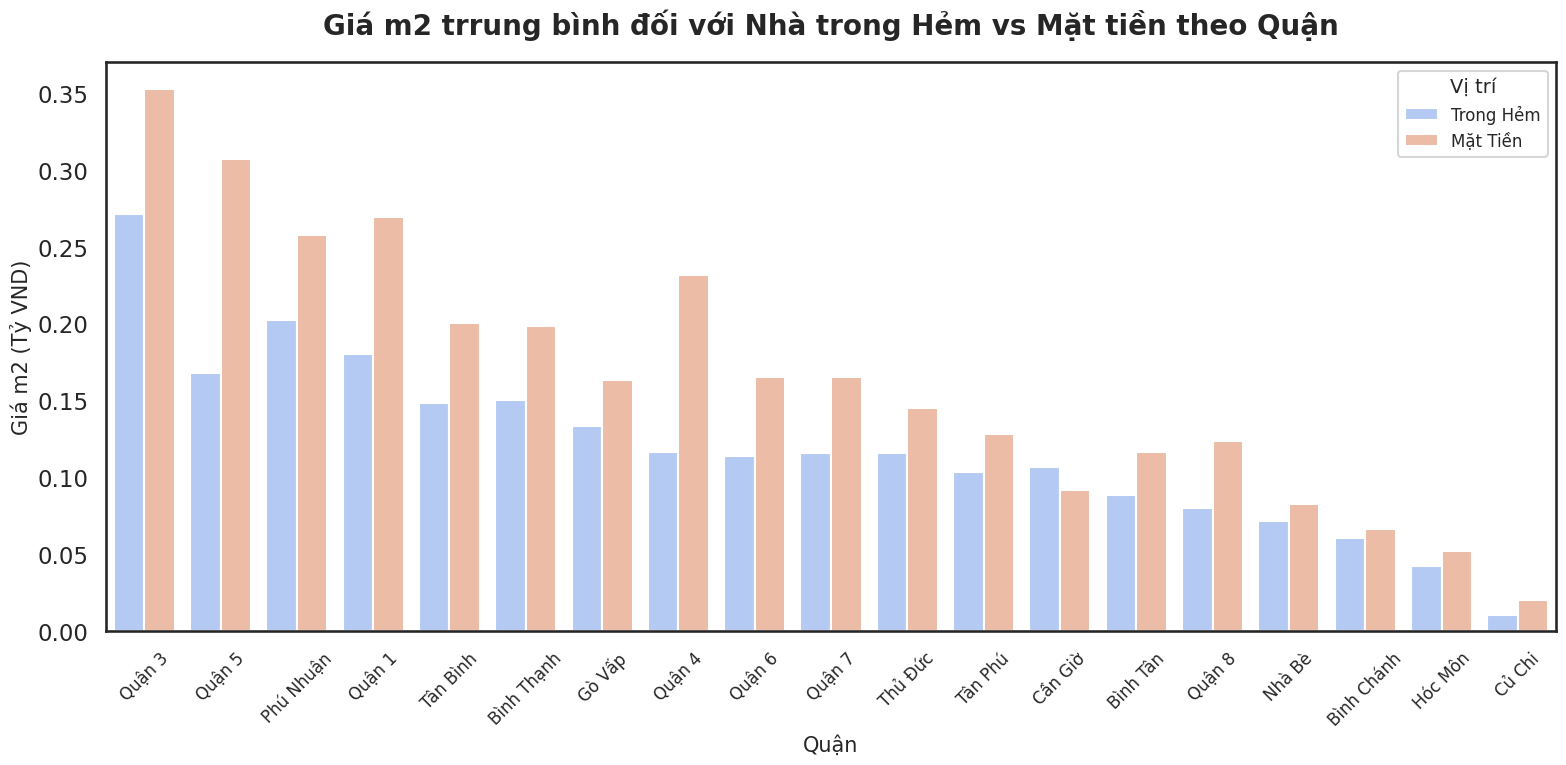

In [ ]:



plt.figure(figsize=(16, 8))
sns.set_context("talk")

district_order = df.groupby('Quận')['Giá m2'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    x='Quận',
    y='Giá m2',
    hue='Mặt tiền',
    data=df,
    order=district_order,
    palette='coolwarm',
    errorbar=None
)

plt.title('Giá m2 trrung bình đối với Nhà trong Hẻm vs Mặt tiền theo Quận', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Giá m2 (Tỷ VND)', fontsize=15)
plt.xlabel('Quận', fontsize=15)
plt.xticks(rotation=45, fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Trong Hẻm', 'Mặt Tiền'], title='Vị trí', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7268/3986909179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


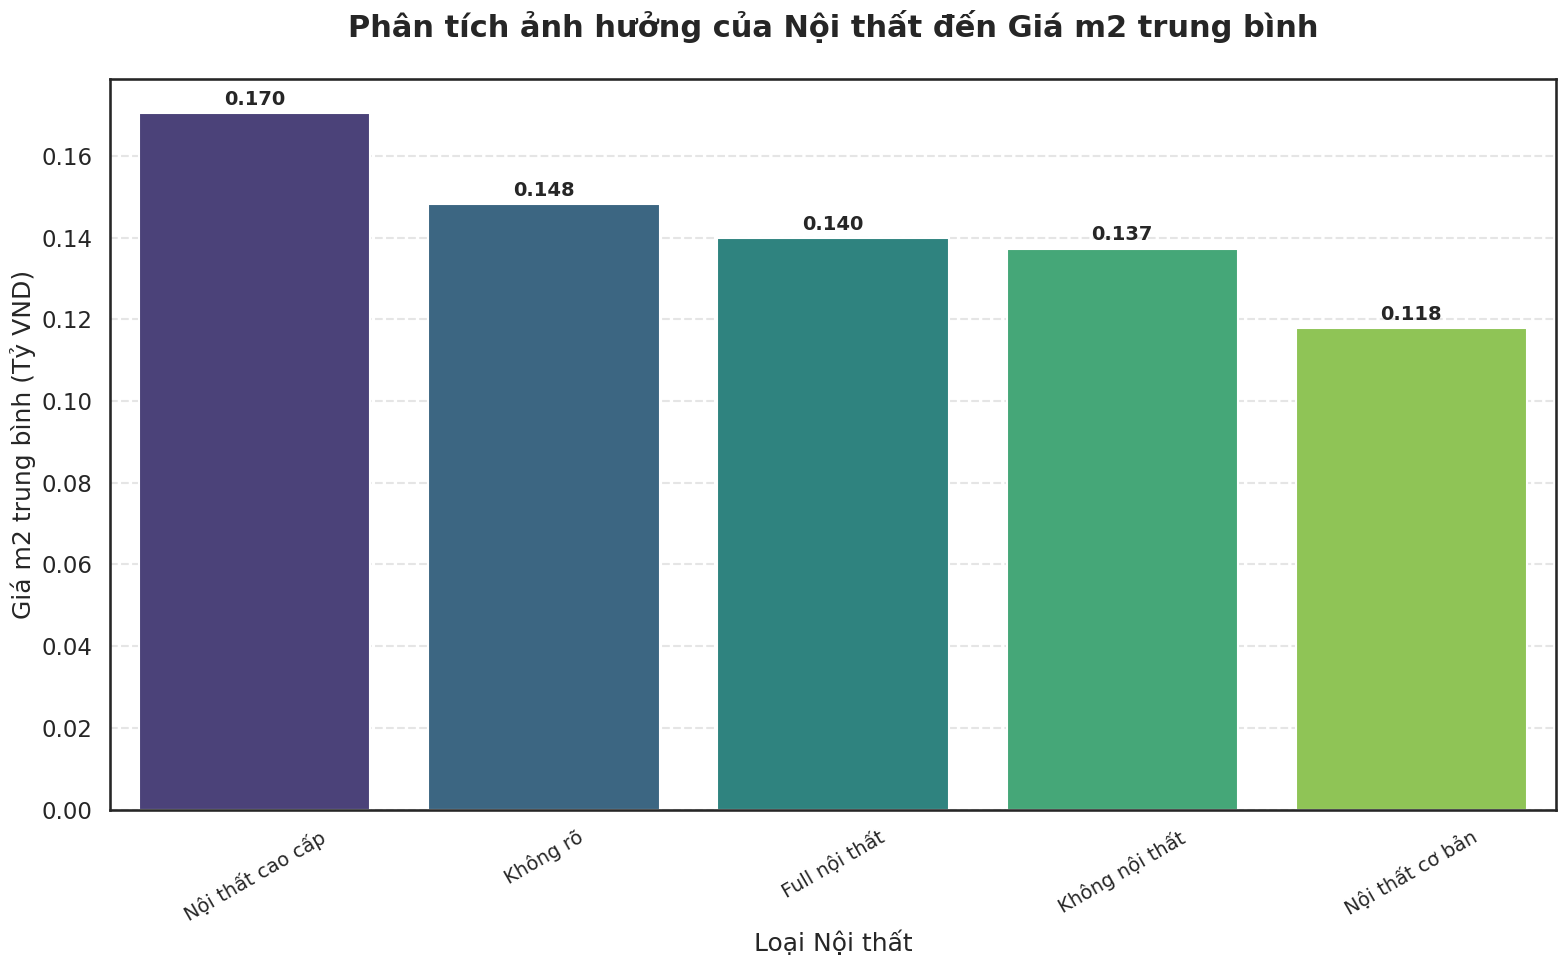

In [ ]:



furniture_order = df.groupby('Nội thất')['Giá m2'].mean().sort_values(ascending=False).index


plt.figure(figsize=(16, 10))
sns.set_context("talk")


ax = sns.barplot(
    x='Nội thất',
    y='Giá m2',
    data=df,
    order=furniture_order,
    palette='viridis',
    errorbar=None
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=14, fontweight='bold')


plt.title('Phân tích ảnh hưởng của Nội thất đến Giá m2 trung bình', fontsize=22, fontweight='bold', pad=30)
plt.ylabel('Giá m2 trung bình (Tỷ VND)', fontsize=18)
plt.xlabel('Loại Nội thất', fontsize=18)
plt.xticks(rotation=30, fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7268/2524392855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Nội thất', y='Giá m2', data=df_plot, order=order, palette='viridis')


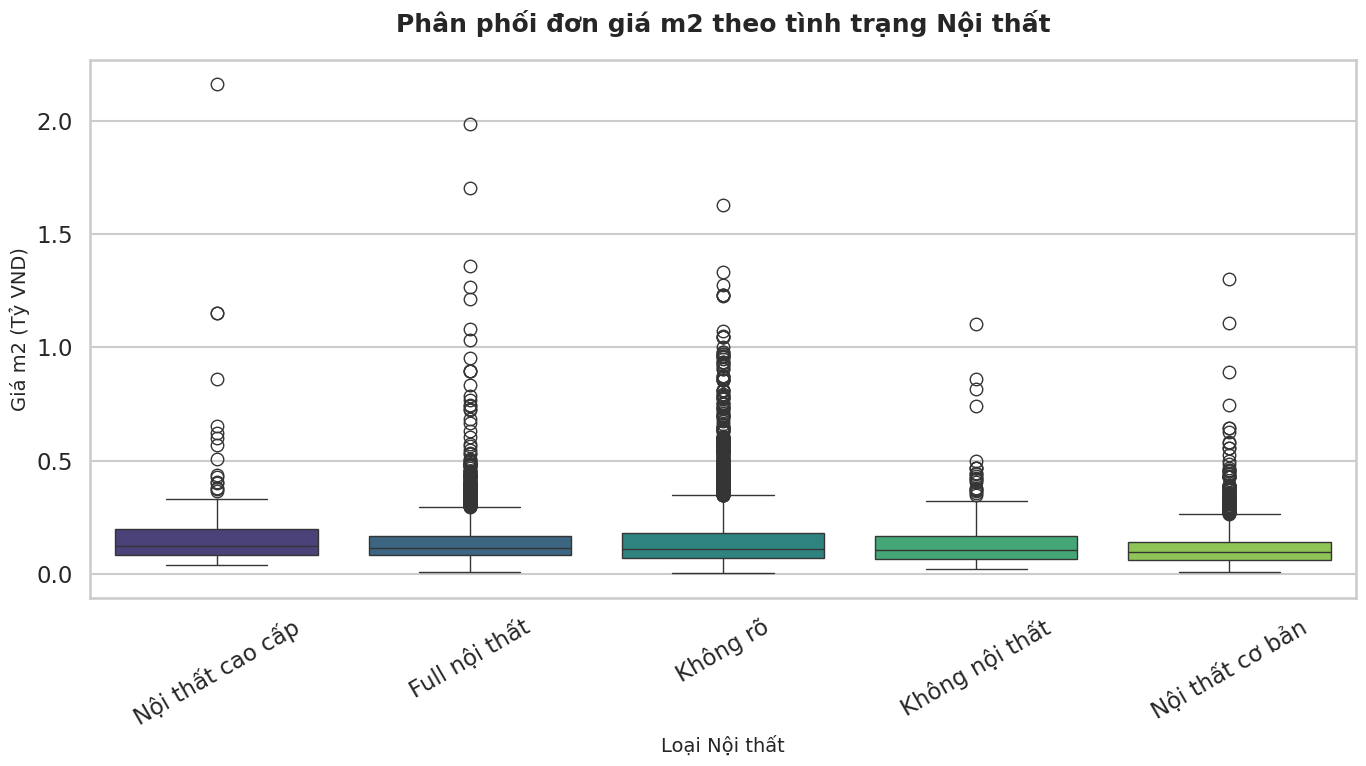

In [ ]:


df_plot = df.dropna(subset=['Nội thất', 'Giá m2']).copy()

order = df_plot.groupby('Nội thất')['Giá m2'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_context("talk")

ax = sns.boxplot(x='Nội thất', y='Giá m2', data=df_plot, order=order, palette='viridis')

plt.title('Phân phối đơn giá m2 theo tình trạng Nội thất', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Loại Nội thất', fontsize=14)
plt.ylabel('Giá m2 (Tỷ VND)', fontsize=14)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7268/2358287884.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


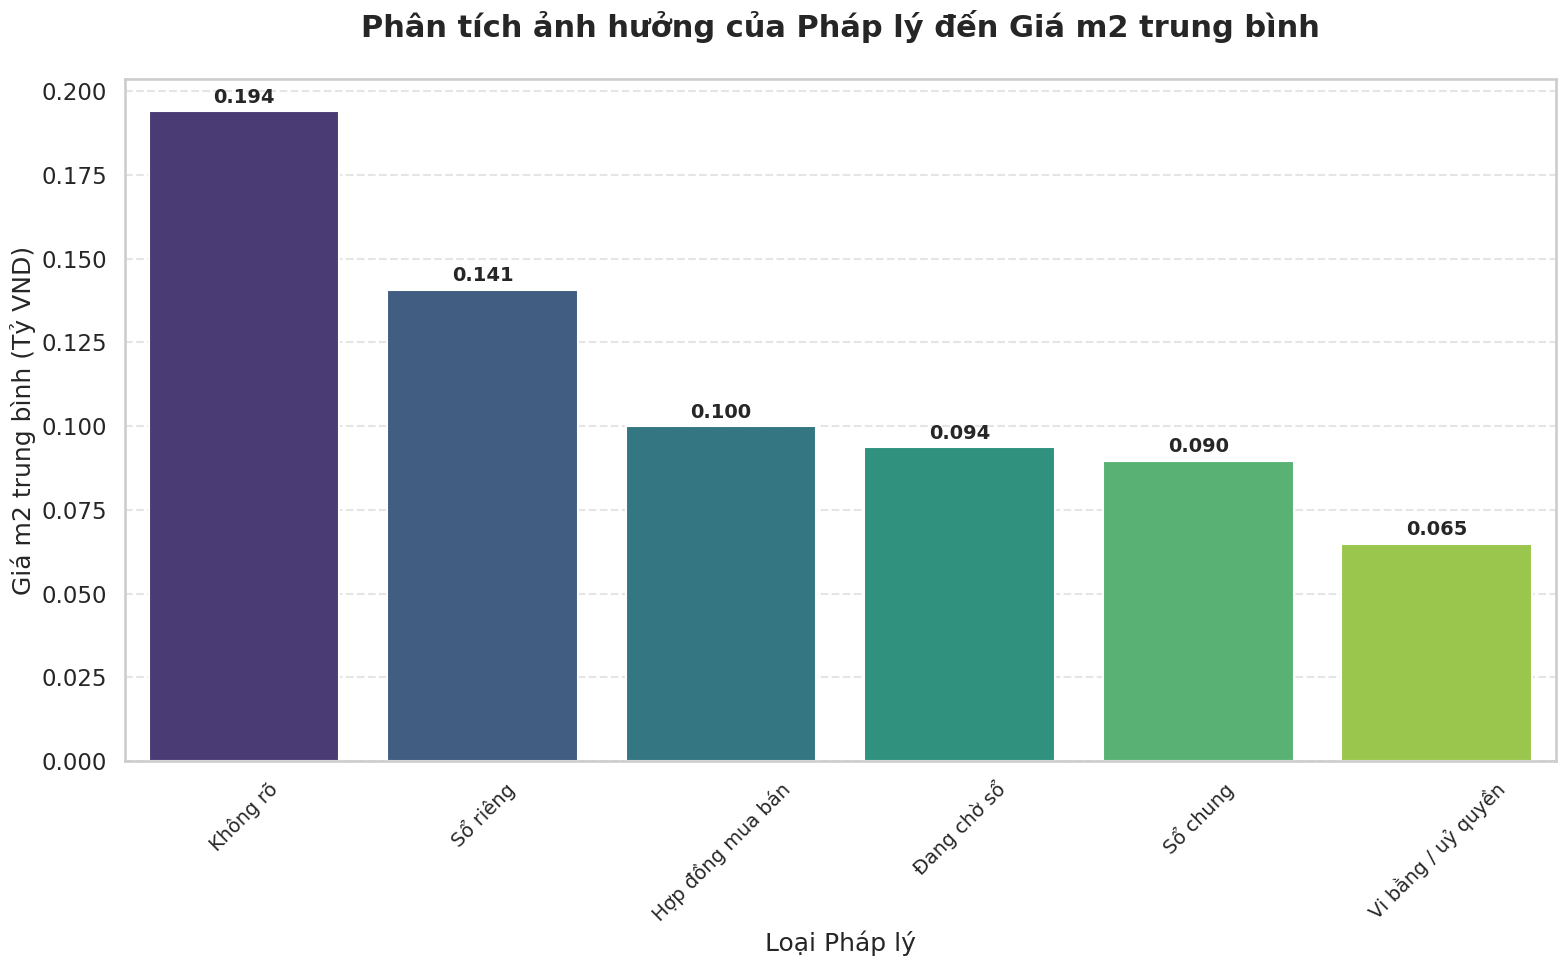

In [ ]:



legal_order = df.groupby('Pháp lý')['Giá m2'].mean().sort_values(ascending=False).index

plt.figure(figsize=(16, 10))
sns.set_context("talk")

ax = sns.barplot(
    x='Pháp lý',
    y='Giá m2',
    data=df,
    order=legal_order,
    palette='viridis',
    errorbar=None
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=14, fontweight='bold')

plt.title('Phân tích ảnh hưởng của Pháp lý đến Giá m2 trung bình', fontsize=22, fontweight='bold', pad=30)
plt.ylabel('Giá m2 trung bình (Tỷ VND)', fontsize=18)
plt.xlabel('Loại Pháp lý', fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11249 entries, 0 to 11248
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID                     11249 non-null  int64   
 1   Diện tích              11249 non-null  float64 
 2   Khoảng giá             11249 non-null  float64 
 3   Số phòng ngủ           11249 non-null  int64   
 4   Số phòng tắm, vệ sinh  11249 non-null  int64   
 5   Pháp lý                11249 non-null  object  
 6   Nội thất               11249 non-null  object  
 7   Ngày hết hạn           11249 non-null  object  
 8   Mặt tiền               11249 non-null  int64   
 9   Gần bệnh viện          11249 non-null  int64   
 10  Gần chợ                11249 non-null  int64   
 11  Gần trường học         11249 non-null  int64   
 12  Cao tầng               11249 non-null  int64   
 13  Quy hoạch              11249 non-null  int64   
 14  Phường                 11249 non-null 

/tmp/ipykernel_7268/3932290698.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


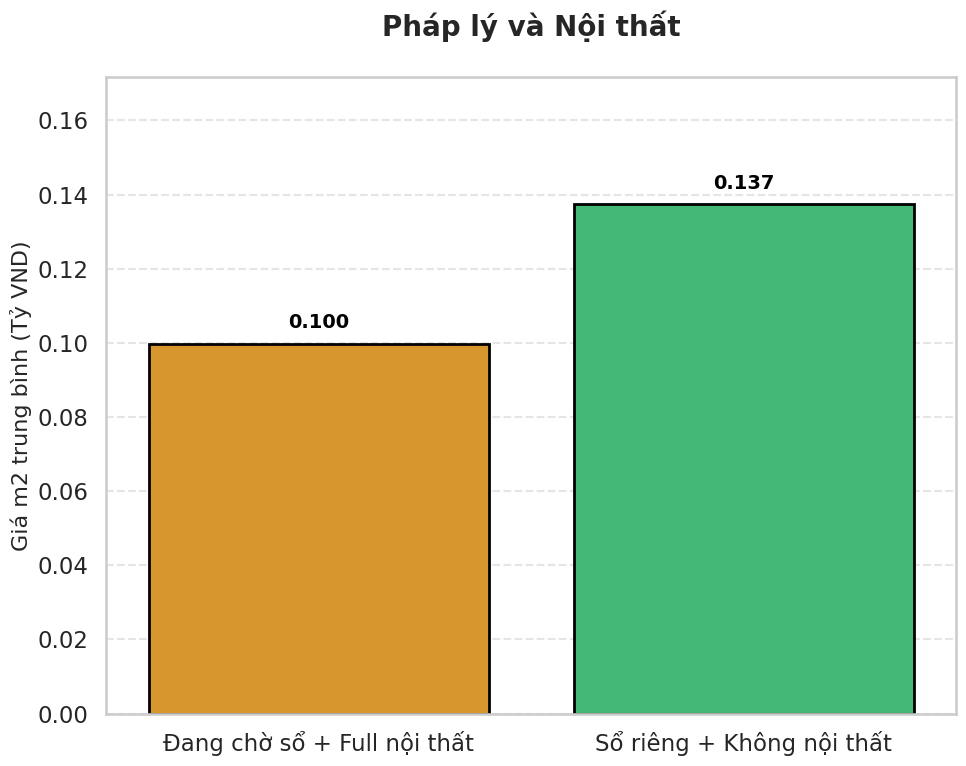

Số lượng căn Đang chờ sổ + Full nội thất: 51
Số lượng căn Sổ riêng + Không nội thất: 267


In [ ]:




s1_mask = (df['Pháp lý'] == 'Đang chờ sổ') & (df['Nội thất'] == 'Full nội thất')

s2_mask = (df['Pháp lý'] == 'Sổ riêng') & (df['Nội thất'] == 'Không nội thất')

s1_data = df[s1_mask].copy()
s1_data['Nhóm so sánh'] = 'Đang chờ sổ + Full nội thất'

s2_data = df[s2_mask].copy()
s2_data['Nhóm so sánh'] = 'Sổ riêng + Không nội thất'

df_compare = pd.concat([s1_data, s2_data])

plt.figure(figsize=(10, 8))
sns.set_context("talk")

colors = ['#f39c12', '#2ecc71']

ax = sns.barplot(
    x='Nhóm so sánh',
    y='Giá m2',
    data=df_compare,
    palette=colors,
    errorbar=None,
    edgecolor='black',
    linewidth=2
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 15),
                textcoords='offset points',
                fontsize=14, fontweight='bold',
                color='black')

plt.title('Pháp lý và Nội thất',
          fontsize=20, fontweight='bold', pad=30)
plt.ylabel('Giá m2 trung bình (Tỷ VND)', fontsize=16)
plt.xlabel('')
plt.ylim(0, df_compare.groupby('Nhóm so sánh')['Giá m2'].mean().max() * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Số lượng căn Đang chờ sổ + Full nội thất: {len(s1_data)}")
print(f"Số lượng căn Sổ riêng + Không nội thất: {len(s2_data)}")

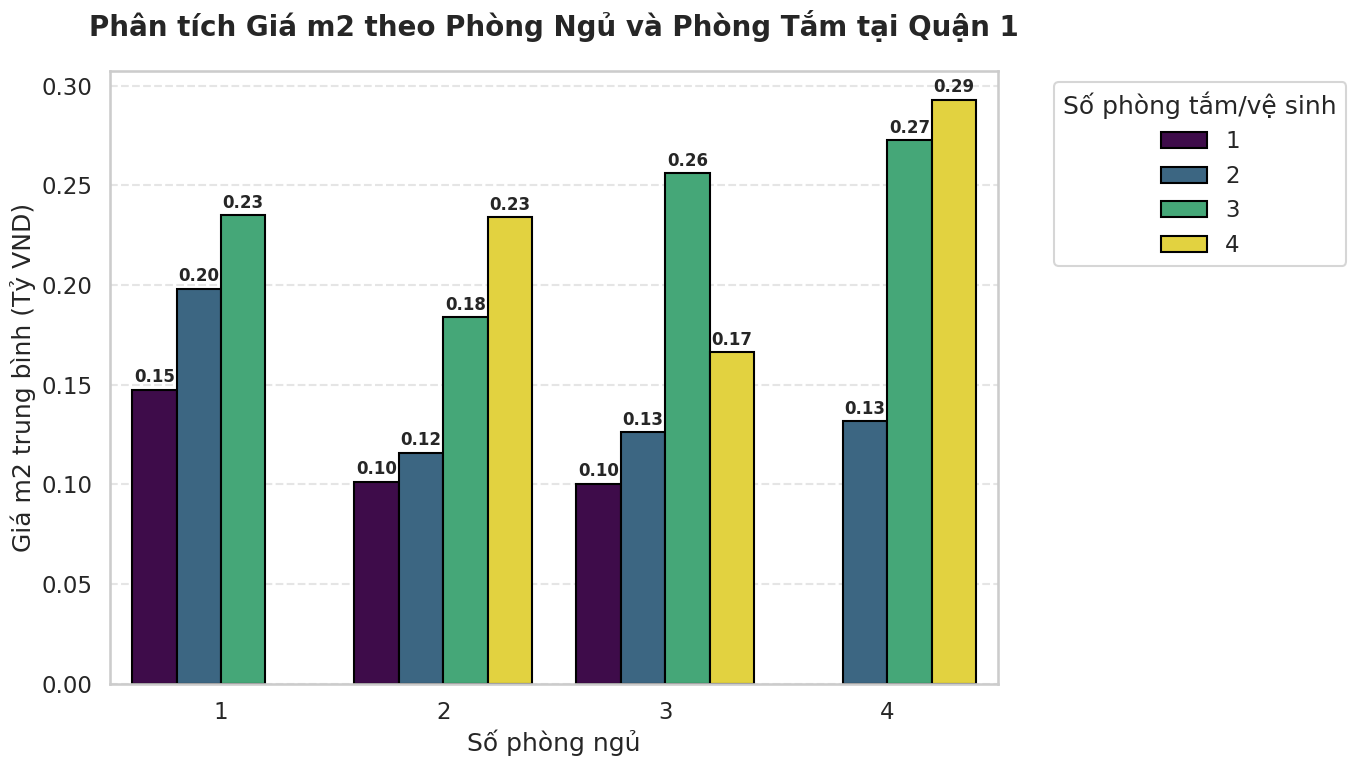

In [ ]:


target_district = 'Quận 1'
df_district = df[df['Quận'] == target_district].copy()

valid_range = [1, 2, 3, 4]
df_plot = df_district[df_district['Số phòng ngủ'].isin(valid_range) &
                      df_district['Số phòng tắm, vệ sinh'].isin(valid_range)].copy()

plt.figure(figsize=(14, 8))
sns.set_context("talk")

ax = sns.barplot(
    x='Số phòng ngủ',
    y='Giá m2',
    hue='Số phòng tắm, vệ sinh',
    data=df_plot,
    palette='viridis',
    errorbar=None,
    edgecolor='black'
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

plt.title(f'Phân tích Giá m2 theo Phòng Ngủ và Phòng Tắm tại {target_district}', fontsize=20, fontweight='bold', pad=25)
plt.ylabel('Giá m2 trung bình (Tỷ VND)')
plt.xlabel('Số phòng ngủ')
plt.legend(title='Số phòng tắm/vệ sinh', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7268/6759071.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Convenience_Score', y='Giá m2', data=df, palette='YlGnBu', errorbar=None)


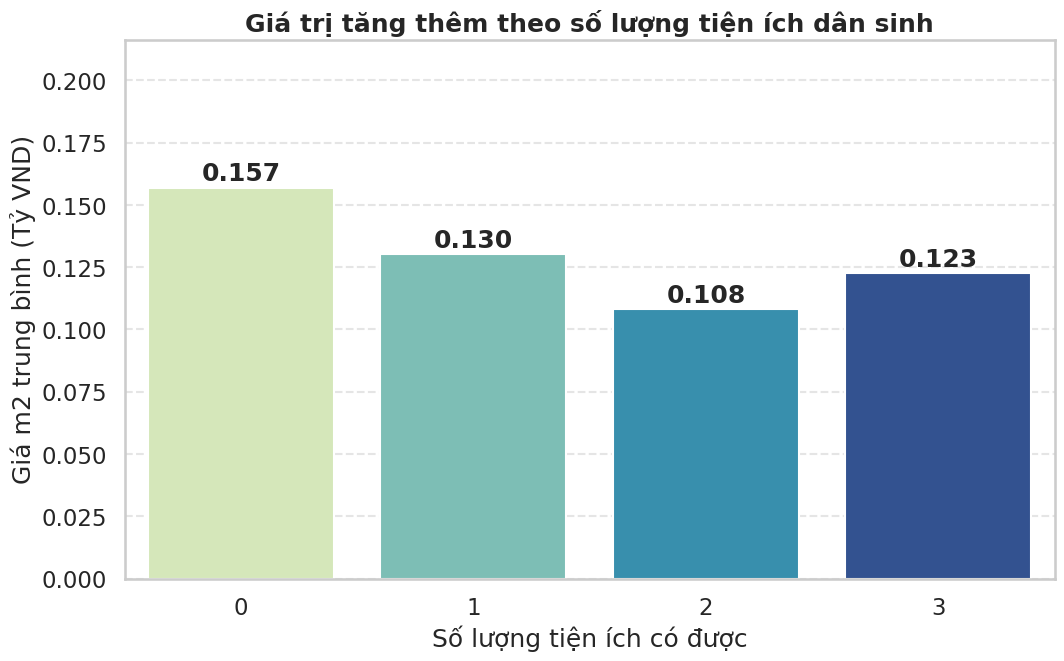

In [ ]:


amenities = ['Gần bệnh viện', 'Gần chợ', 'Gần trường học']
df['Convenience_Score'] = df[amenities].sum(axis=1)

plt.figure(figsize=(12, 7))
sns.set_context("talk")

ax = sns.barplot(x='Convenience_Score', y='Giá m2', data=df, palette='YlGnBu', errorbar=None)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontweight='bold')
ax.set_ylim(0, df['Giá m2'].max() * 0.1)

plt.title('Giá trị tăng thêm theo số lượng tiện ích dân sinh', fontsize=18, fontweight='bold')
plt.xlabel('Số lượng tiện ích có được')
plt.ylabel('Giá m2 trung bình (Tỷ VND)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

df_melted = df.melt(id_vars=['Giá m2'], value_vars=amenities, var_name='Loai_Tien_Ich', value_name='Co_Hay_Khong')
df_present = df_melted[df_melted['Co_Hay_Khong'] == 1]

/tmp/ipykernel_7268/866655638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Loại hình', y='Giá m2', data=df_type, palette='Set2', errorbar=None, edgecolor='black')


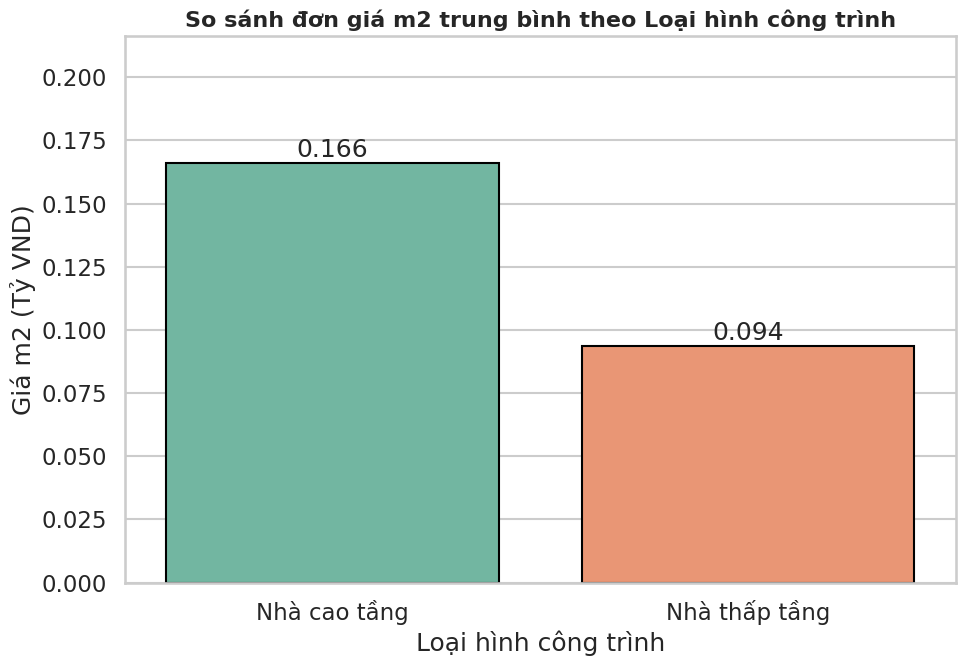

                mean  median    std  count
Loại hình                                 
Nhà cao tầng   0.166   0.131  0.135   7377
Nhà thấp tầng  0.094   0.076  0.072   3872


In [ ]:
df_type = df.dropna(subset=['Cao tầng', 'Giá m2']).copy()

df_type['Loại hình'] = df_type['Cao tầng'].map({0: 'Nhà thấp tầng', 1: 'Nhà cao tầng'})

plt.figure(figsize=(10, 7))
sns.set_context("talk")

ax = sns.barplot(x='Loại hình', y='Giá m2', data=df_type, palette='Set2', errorbar=None, edgecolor='black')

plt.title('So sánh đơn giá m2 trung bình theo Loại hình công trình', fontsize=16, fontweight='bold')
plt.xlabel('Loại hình công trình')
plt.ylabel('Giá m2 (Tỷ VND)')
ax.set_ylim(0, df_type['Giá m2'].max() * 0.1)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

stats = df_type.groupby('Loại hình')['Giá m2'].agg(['mean', 'median', 'std', 'count']).round(3)
print(stats)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11249 entries, 0 to 11248
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID                     11249 non-null  int64   
 1   Diện tích              11249 non-null  float64 
 2   Khoảng giá             11249 non-null  float64 
 3   Số phòng ngủ           11249 non-null  int64   
 4   Số phòng tắm, vệ sinh  11249 non-null  int64   
 5   Pháp lý                11249 non-null  object  
 6   Nội thất               11249 non-null  object  
 7   Ngày hết hạn           11249 non-null  object  
 8   Mặt tiền               11249 non-null  int64   
 9   Gần bệnh viện          11249 non-null  int64   
 10  Gần chợ                11249 non-null  int64   
 11  Gần trường học         11249 non-null  int64   
 12  Cao tầng               11249 non-null  int64   
 13  Quy hoạch              11249 non-null  int64   
 14  Phường                 11249 non-null 

<Figure size 1600x900 with 0 Axes>

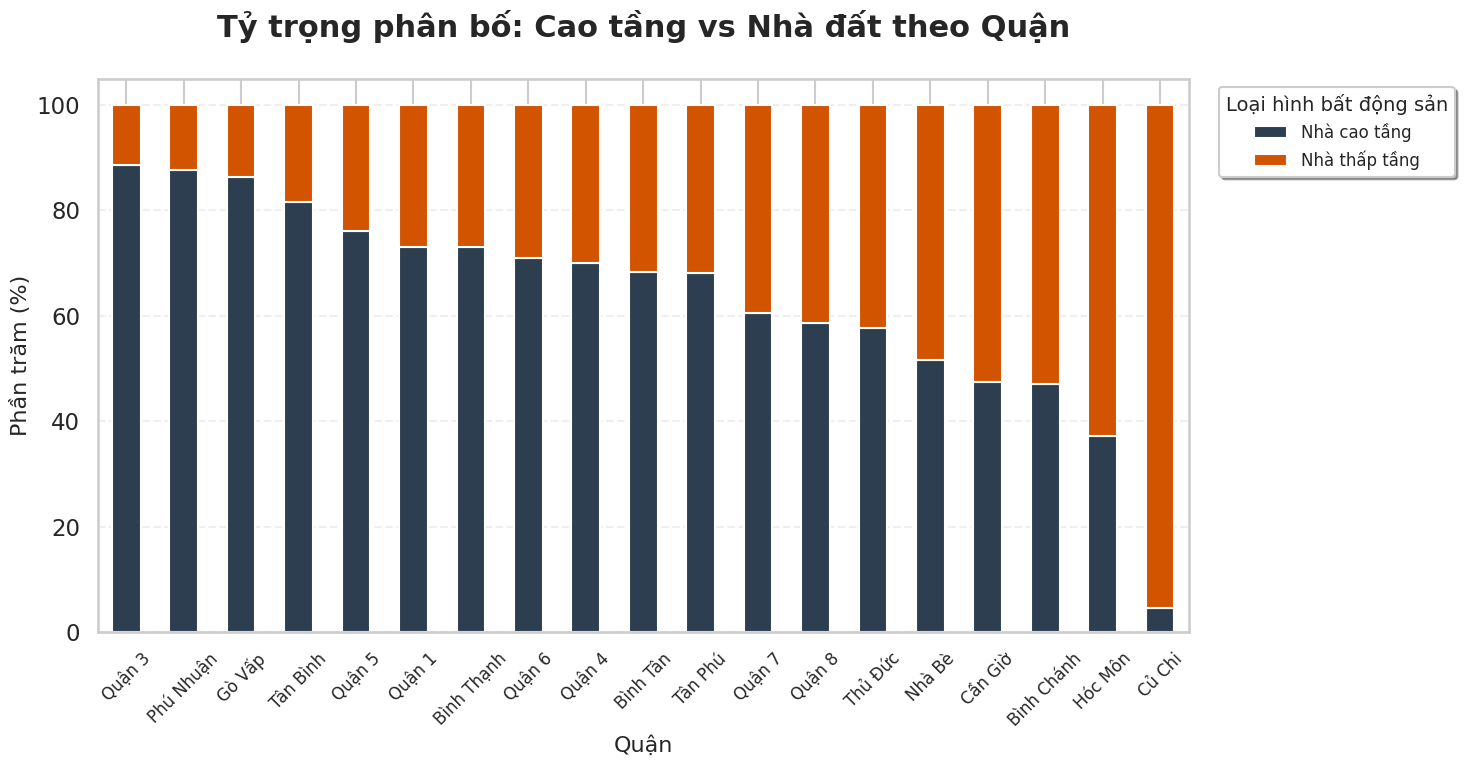

Top 5 Quận có tỷ lệ Cao tầng cao nhất:
Loại hình  Nhà cao tầng  Nhà thấp tầng
Quận                                  
Quận 3            88.60          11.40
Phú Nhuận         87.66          12.34
Gò Vấp            86.28          13.72
Tân Bình          81.57          18.43
Quận 5            76.19          23.81


In [ ]:


df_plot = df.dropna(subset=['Cao tầng', 'Quận']).copy()

df_plot['Loại hình'] = df_plot['Cao tầng'].map({0: 'Nhà thấp tầng', 1: 'Nhà cao tầng'})

dist_type_counts = pd.crosstab(df_plot['Quận'], df_plot['Loại hình'])

dist_type_pct = dist_type_counts.div(dist_type_counts.sum(axis=1), axis=0) * 100

if 'Nhà cao tầng' in dist_type_pct.columns:
    dist_type_pct = dist_type_pct.sort_values(by='Nhà cao tầng', ascending=False)

plt.figure(figsize=(16, 9))
sns.set_context("talk")

colors = ['#2c3e50', '#d35400']
ax = dist_type_pct.plot(kind='bar', stacked=True, figsize=(15, 8), color=colors, edgecolor='white')

plt.title('Tỷ trọng phân bố: Cao tầng vs Nhà đất theo Quận', fontsize=22, fontweight='bold', pad=30)
plt.ylabel('Phần trăm (%)', fontsize=16)
plt.xlabel('Quận', fontsize=16)
plt.xticks(rotation=45, fontsize=12)

plt.legend(title='Loại hình bất động sản',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize=12,
           title_fontsize=14,
           frameon=True,
           shadow=True)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 Quận có tỷ lệ Cao tầng cao nhất:")
print(dist_type_pct.head(5).round(2))

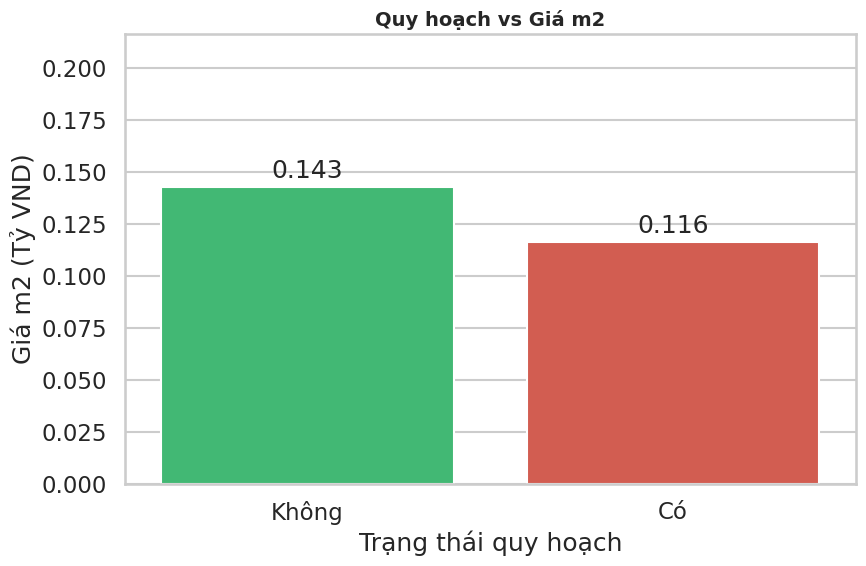

In [ ]:
plt.figure(figsize=(9, 6))

df['Tình trạng'] = df['Quy hoạch'].map({0: 'Không', 1: 'Có'})

ax = sns.barplot(
    x='Tình trạng',
    y='Giá m2',
    hue='Tình trạng',
    data=df,
    errorbar=None,
    palette=['#2ecc71', '#e74c3c']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

ax.set_ylim(0, df['Giá m2'].max() * 0.1)
plt.title('Quy hoạch vs Giá m2', fontsize=14, fontweight='bold')
plt.ylabel('Giá m2 (Tỷ VND)')
plt.xlabel('Trạng thái quy hoạch')


plt.tight_layout()
plt.show()

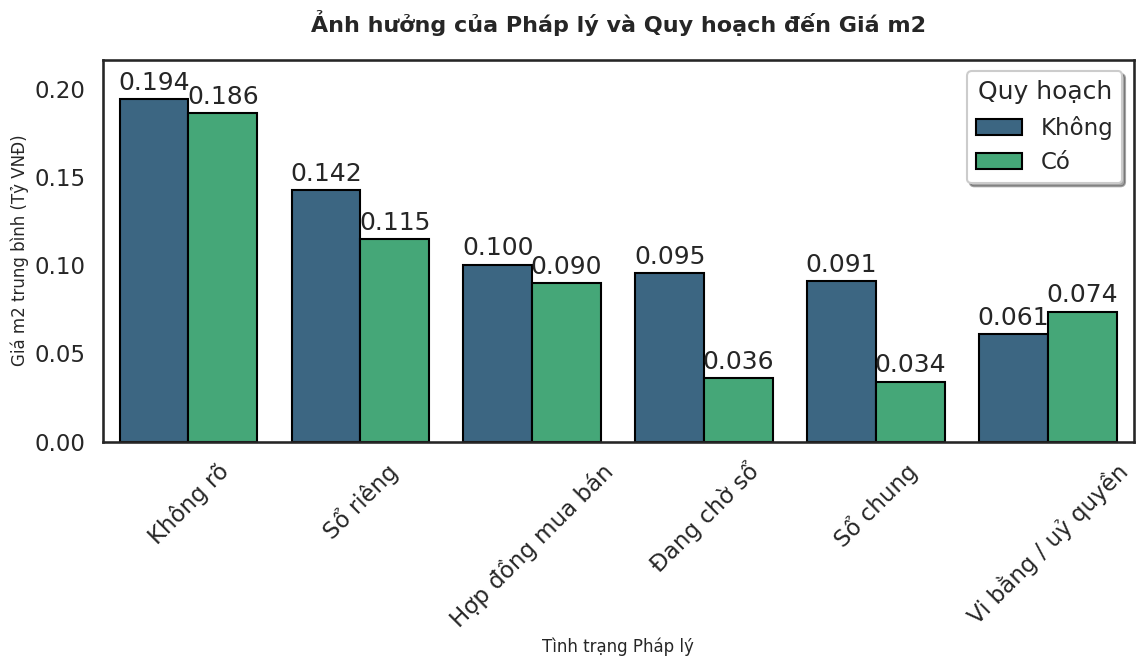

In [ ]:
grouped_df = df.groupby(['Quy hoạch', 'Pháp lý'])['Giá m2'].mean().reset_index()

grouped_df['Quy hoạch'] = grouped_df['Quy hoạch'].map({0: 'Không', 1: 'Có'})

grouped_df = grouped_df.sort_values(by='Giá m2', ascending=False)

sns.set_style("white")

plt.figure(figsize=(12, 7))


ax = sns.barplot(
    data=grouped_df,
    x='Pháp lý',
    y='Giá m2',
    hue='Quy hoạch',
    palette='viridis',
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
ax.set_ylim(0, df['Giá m2'].max() * 0.1)
plt.title('Ảnh hưởng của Pháp lý và Quy hoạch đến Giá m2', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Giá m2 trung bình (Tỷ VNĐ)', fontsize=12)
plt.xlabel('Tình trạng Pháp lý', fontsize=12)
plt.xticks(rotation=45)

plt.legend(title='Quy hoạch', loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()